# Prédiction de prix d'action avec un LSTM (PyTorch)

But simple : prédire le prix de clôture de demain à partir des prix des jours précédents.

Étapes :
1. Installer les librairies
2. Charger et préparer les données
3. Créer le Dataset et le DataLoader
4. Créer le modèle LSTM
5. Entraîner le modèle
6. Évaluer le modèle


## 1. Installer les librairies nécessaires

In [1]:
# Si une librairie manque, décommente la ligne pip install
# !pip install gensim spacy torch scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import pickle

print("Torch version:", torch.__version__)

torch.manual_seed(42)
np.random.seed(42)


Torch version: 2.12.1+cu130


## 2. Charger et préparer les données

On utilise normalement le dataset Kaggle ici :
https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset

Le dataset contient un fichier CSV par action, avec les colonnes :
`Date, Open, High, Low, Close, Adj Close, Volume`.

### Note importante

Dans cet environnement, je n'ai pas accès à Kaggle pour télécharger le vrai
fichier. Le code ci-dessous essaie de charger un fichier CSV local (par
exemple `AAPL.csv`), et si le fichier n'existe pas, il **génère des données
de prix simulées** (un prix qui bouge un peu chaque jour, comme une vraie
action) pour que le reste du notebook fonctionne quand même.

**Dans ton Colab avec le vrai dataset téléchargé**, mets simplement le bon
nom de fichier dans `CSV_PATH` ci-dessous, et tout le reste du code marche
pareil, sans rien changer.


In [2]:
CSV_PATH = 'AAPL.csv'  # change ce nom si tu utilises une autre action

try:
    df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
    print(f"Fichier '{CSV_PATH}' chargé.")
except FileNotFoundError:
    print(f"Fichier '{CSV_PATH}' non trouvé. Création de données simulées à la place.")

    n_days = 1500
    dates = pd.date_range('2018-01-01', periods=n_days, freq='B')

    # Simulation simple d'un prix d'action (marche aléatoire avec petite tendance)
    returns = np.random.normal(loc=0.0003, scale=0.015, size=n_days)
    price = 100 * np.exp(np.cumsum(returns))

    close = price
    open_ = close * (1 + np.random.normal(0, 0.003, n_days))
    high = np.maximum(open_, close) * (1 + np.abs(np.random.normal(0, 0.004, n_days)))
    low = np.minimum(open_, close) * (1 - np.abs(np.random.normal(0, 0.004, n_days)))
    volume = np.random.randint(1_000_000, 5_000_000, n_days)

    df = pd.DataFrame({
        'Date': dates,
        'Open': open_,
        'High': high,
        'Low': low,
        'Close': close,
        'Adj Close': close,
        'Volume': volume
    })

print(df.shape)
df.head()


Fichier 'AAPL.csv' non trouvé. Création de données simulées à la place.
(1500, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-01,101.013408,101.784264,100.391587,100.778083,100.778083,3202661
1,2018-01-02,100.433117,100.945682,99.889771,100.599464,100.599464,1355752
2,2018-01-03,101.362647,101.780173,100.720580,101.612063,101.612063,2162886
3,2018-01-04,103.990296,104.776561,103.818504,103.991349,103.991349,3929386
4,2018-01-05,103.604910,103.888598,103.516196,103.657833,103.657833,4869108


### Garder seulement les colonnes utiles

On garde `Close` (prix de clôture) et `Volume`. On enlève `Date` (pas un
nombre utilisable directement) et les autres colonnes redondantes.


In [3]:
df = df[['Close', 'Volume']].copy()

print("Valeurs manquantes :")
print(df.isnull().sum())

df = df.dropna().reset_index(drop=True)
print("\nShape après nettoyage :", df.shape)
df.head()


Valeurs manquantes :
Close     0
Volume    0
dtype: int64

Shape après nettoyage : (1500, 2)


,Close,Volume
0,100.778083,3202661
1,100.599464,1355752
2,101.612063,2162886
3,103.991349,3929386
4,103.657833,4869108


### Visualiser le prix de clôture

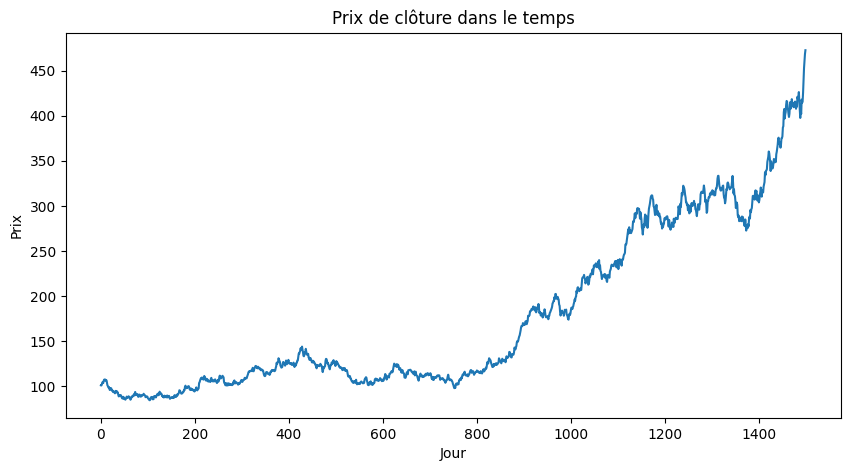

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df['Close'])
plt.title('Prix de clôture dans le temps')
plt.xlabel('Jour')
plt.ylabel('Prix')
plt.show()


### Créer la colonne cible : prix de clôture du jour suivant

`Target` = le `Close` du jour d'après. C'est ce que le modèle doit prédire.


In [5]:
df['Target'] = df['Close'].shift(-1)

# La dernière ligne n'a pas de jour "suivant", donc on la supprime
df = df.dropna().reset_index(drop=True)

df.head()


,Close,Volume,Target
0,100.778083,3202661,100.599464
1,100.599464,1355752,101.612063
2,101.612063,2162886,103.991349
3,103.991349,3929386,103.657833
4,103.657833,4869108,103.325413


### Normaliser les données avec `MinMaxScaler`

Un LSTM apprend mieux quand les nombres sont petits (entre 0 et 1). On
normalise `Close`, `Volume` et `Target` séparément avec un scaler pour les
features (X) et un scaler pour la cible (y), pour pouvoir "dénormaliser"
facilement la prédiction plus tard.


In [6]:
feature_cols = ['Close', 'Volume']
target_col = 'Target'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(df[feature_cols])
y_scaled = target_scaler.fit_transform(df[[target_col]])

print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)
print("\nExemple de valeurs normalisées (X) :")
print(X_scaled[:5])


X_scaled shape: (1499, 2)
y_scaled shape: (1499, 1)

Exemple de valeurs normalisées (X) :
[[0.04301541 0.55076336]
 [0.0425506  0.08891002]
 [0.04518565 0.29074862]
 [0.05137719 0.73249422]
 [0.05050929 0.96748887]]


## 3. Préparer les données pour l'entraînement

### Créer des séquences

Un LSTM a besoin d'une **séquence** de jours pour prédire le jour suivant.
On utilise les `SEQ_LENGTH` derniers jours pour prédire le jour d'après.


In [7]:
SEQ_LENGTH = 20  # nombre de jours utilisés pour prédire le jour suivant

def create_sequences(X, y, seq_length):
    """Transforme les données en séquences (X) et valeurs cibles (y)."""
    sequences = []
    targets = []
    for i in range(len(X) - seq_length):
        sequences.append(X[i:i + seq_length])
        targets.append(y[i + seq_length])
    return np.array(sequences), np.array(targets)


X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LENGTH)

print("X_seq shape:", X_seq.shape)  # (nombre de séquences, SEQ_LENGTH, nombre de features)
print("y_seq shape:", y_seq.shape)


X_seq shape: (1479, 20, 2)
y_seq shape: (1479, 1)


### Split train / validation / test

On découpe dans l'ordre du temps (pas aléatoire), car c'est une série
temporelle : on entraîne sur le passé, on teste sur le futur.

- 70% train
- 15% validation
- 15% test


In [8]:
n = len(X_seq)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (1035, 20, 2) (1035, 1)
Val  : (222, 20, 2) (222, 1)
Test : (222, 20, 2) (222, 1)


### Créer une classe `Dataset` personnalisée

`torch.utils.data.Dataset` est une classe de base. On doit définir 3 méthodes :
- `__init__` : stocker les données
- `__len__` : dire combien d'exemples il y a
- `__getitem__` : retourner un exemple (X, y) à un index donné


In [9]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

print("Nombre d'exemples - train:", len(train_dataset), "| val:", len(val_dataset), "| test:", len(test_dataset))


Nombre d'exemples - train: 1035 | val: 222 | test: 222


### Créer les `DataLoader`

Le `DataLoader` découpe le dataset en petits paquets (`batch_size`) et peut
mélanger les données (`shuffle=True`) à chaque epoch pour l'entraînement.


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Vérifier la forme d'un batch
sample_X, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)  # (batch_size, SEQ_LENGTH, nombre de features)
print("Batch y shape:", sample_y.shape)


Batch X shape: torch.Size([32, 20, 2])
Batch y shape: torch.Size([32, 1])


## 4. Définir le modèle LSTM

Le modèle :
- une couche `LSTM` qui lit la séquence
- une couche `Dropout` pour éviter le surapprentissage
- une couche `Linear` (dense) qui donne la prédiction finale (1 nombre)


In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)

        # On garde seulement la sortie du dernier pas de temps
        last_output = lstm_out[:, -1, :]

        out = self.dropout(last_output)
        out = self.fc(out)
        return out


input_size = X_train.shape[2]  # nombre de features (Close, Volume)
model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(model)
print("\nDevice utilisé:", device)


LSTMModel(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device utilisé: cpu


## 5. Entraîner le modèle

### Optimiseur et fonction de perte

- `Adam` : l'optimiseur, il ajuste les poids du modèle
- `MSELoss` : Mean Squared Error, mesure l'écart entre prédiction et vraie valeur


In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


### Boucle d'entraînement et de validation

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


In [14]:
NUM_EPOCHS = 30

train_losses = []
val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{NUM_EPOCHS} - train_loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")


Epoch 1/30 - train_loss: 0.006248 - val_loss: 0.025307


Epoch 5/30 - train_loss: 0.000337 - val_loss: 0.000771


Epoch 10/30 - train_loss: 0.000264 - val_loss: 0.001249


Epoch 15/30 - train_loss: 0.000261 - val_loss: 0.000916


Epoch 20/30 - train_loss: 0.000248 - val_loss: 0.000686


Epoch 25/30 - train_loss: 0.000242 - val_loss: 0.000560


Epoch 30/30 - train_loss: 0.000197 - val_loss: 0.000558


### Courbe d'apprentissage

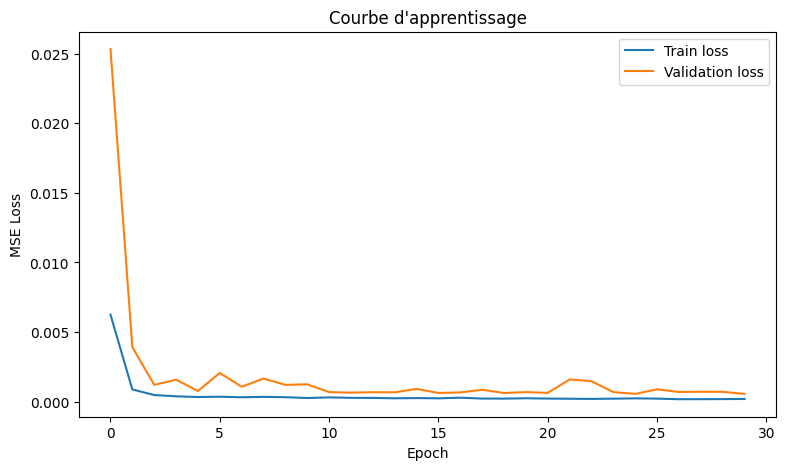

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.show()


**Comment lire ce graphique :** si les deux courbes descendent et se
rapprochent, le modèle apprend bien. Si la courbe de validation remonte
alors que celle d'entraînement continue de descendre, c'est du
surapprentissage (overfitting).


## 6. Évaluer le modèle

### Calculer le score R² sur le jeu de test

Le R² dit quelle part de la variation du prix le modèle arrive à expliquer.
- R² proche de 1 = très bon
- R² proche de 0 = pas mieux que prédire la moyenne
- R² négatif = pire que prédire la moyenne


In [16]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# On dénormalise pour avoir des vrais prix en dollars
preds_real = target_scaler.inverse_transform(all_preds)
targets_real = target_scaler.inverse_transform(all_targets)

r2 = r2_score(targets_real, preds_real)
print(f"R² score sur le jeu de test : {r2:.4f}")


R² score sur le jeu de test : 0.8904


### Visualiser les prédictions vs les vraies valeurs

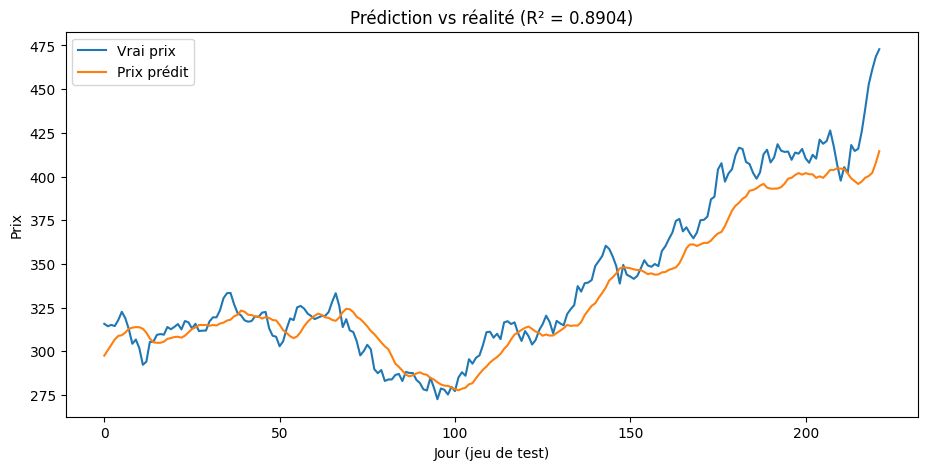

In [17]:
plt.figure(figsize=(11, 5))
plt.plot(targets_real, label='Vrai prix')
plt.plot(preds_real, label='Prix prédit')
plt.xlabel('Jour (jeu de test)')
plt.ylabel('Prix')
plt.title(f'Prédiction vs réalité (R² = {r2:.4f})')
plt.legend()
plt.show()


### Sauvegarder le modèle et le scaler

On sauvegarde :
- les poids du modèle (`torch.save`)
- les scalers (avec `pickle`), pour pouvoir refaire les mêmes prédictions plus tard


In [18]:
torch.save(model.state_dict(), 'lstm_stock_model.pth')
print("Modèle sauvegardé dans 'lstm_stock_model.pth'")

with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)

with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

print("Scalers sauvegardés dans 'feature_scaler.pkl' et 'target_scaler.pkl'")


Modèle sauvegardé dans 'lstm_stock_model.pth'
Scalers sauvegardés dans 'feature_scaler.pkl' et 'target_scaler.pkl'


In [19]:
# Vérifier que le modèle se recharge bien
reloaded_model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)
reloaded_model.load_state_dict(torch.load('lstm_stock_model.pth'))
reloaded_model.eval()

print("Modèle rechargé avec succès.")


Modèle rechargé avec succès.


## Résumé

1. On a chargé les données et créé une cible (`Target` = prix du jour suivant).
2. On a normalisé les données avec `MinMaxScaler`.
3. On a créé des séquences de 20 jours, un `Dataset` et des `DataLoader`.
4. On a défini un modèle LSTM (LSTM + Dropout + Linear).
5. On a entraîné le modèle avec Adam et MSELoss.
6. On a évalué le modèle avec le score R² et sauvegardé le modèle + les scalers.

**Note :** ce notebook tourne ici sur des données simulées (pas le vrai
dataset Kaggle), donc le R² obtenu n'a pas de sens réel pour de la vraie
prédiction boursière. Avec le vrai fichier CSV (une vraie action), il
suffit de changer `CSV_PATH` en haut du notebook — tout le reste du code
fonctionne pareil.
